# Heart Disease Prediction - Supervised Learning Models

## Classification Models Training and Evaluation

### Objectives
- Train multiple classification models on the heart disease dataset
- Compare model performance using comprehensive evaluation metrics
- Visualize results with ROC curves, confusion matrices, and feature importance
- Select the best performing model for deployment

### Models to Train
1. **Logistic Regression**: Linear probabilistic classifier
2. **Decision Tree**: Rule-based tree classifier
3. **Random Forest**: Ensemble of decision trees
4. **Support Vector Machine (SVM)**: Margin-based classifier

### Evaluation Metrics
- **Accuracy**: Overall correct predictions
- **Precision**: True positives / (True positives + False positives)
- **Recall**: True positives / (True positives + False negatives)
- **F1-Score**: Harmonic mean of precision and recall
- **ROC-AUC**: Area under the receiver operating characteristic curve

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix,
    classification_report, precision_recall_curve
)
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from datetime import datetime

# Configure settings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("✅ Libraries imported successfully!")
print("🤖 Ready for supervised learning model training")

✅ Libraries imported successfully!
🤖 Ready for supervised learning model training


## 1. Load Processed Data

Load the dataset with selected features from previous notebooks:

In [2]:
# Try to load dataset with selected features, fallback to processed dataset
try:
    df = pd.read_csv('../data/heart_disease_selected_features.csv')
    print(f"✅ Selected features dataset loaded: {df.shape}")
    data_source = "selected_features"
except FileNotFoundError:
    try:
        df = pd.read_csv('../data/heart_disease_processed.csv')
        print(f"✅ Processed dataset loaded: {df.shape}")
        data_source = "processed"
    except FileNotFoundError:
        print("❌ No processed dataset found. Please run previous notebooks first.")
        df = None

if df is not None:
    # Prepare features and target
    X = df.drop('target', axis=1)
    y = df['target']
    
    print(f"\n📊 Dataset Information:")
    print(f"Features: {X.shape[1]}")
    print(f"Instances: {X.shape[0]}")
    print(f"Data source: {data_source}")
    
    # Display class distribution
    print(f"\n🎯 Target Distribution:")
    target_counts = y.value_counts().sort_index()
    for class_val, count in target_counts.items():
        percentage = (count / len(y)) * 100
        class_name = "No Disease" if class_val == 0 else "Disease"
        print(f"{class_name}: {count} ({percentage:.1f}%)")
    
    # Show feature names
    print(f"\n📋 Features: {list(X.columns)}")
    
    # Display first few rows
    print(f"\n👀 First 5 rows:")
    display(df.head())
else:
    print("Cannot proceed without data")

✅ Selected features dataset loaded: (920, 12)

📊 Dataset Information:
Features: 11
Instances: 920
Data source: selected_features

🎯 Target Distribution:
No Disease: 411 (44.7%)
Disease: 509 (55.3%)

📋 Features: ['cp', 'oldpeak', 'exang', 'thalach', 'age', 'chol', 'fbs', 'slope', 'ca', 'sex', 'thal']

👀 First 5 rows:


,cp,oldpeak,exang,thalach,age,chol,fbs,slope,ca,sex,thal,target
0,1.0,1.368109,0.0,0.489727,1.007386,-0.212194,1.0,3.0,0.0,1.0,6.0,0
1,4.0,0.611589,1.0,-1.181478,1.432034,0.807376,0.0,2.0,3.0,1.0,3.0,1
2,4.0,1.651804,1.0,-0.345875,1.432034,-0.289143,0.0,2.0,2.0,1.0,7.0,1
3,3.0,2.502889,0.0,1.961979,-1.752828,0.114838,0.0,3.0,0.0,1.0,3.0,0
4,2.0,0.517024,0.0,1.365120,-1.328180,-0.770073,0.0,1.0,0.0,0.0,3.0,0


## 2. Data Splitting and Preparation

Split the data into training and testing sets:

In [3]:
# Split data into training and testing sets
if 'X' in locals() and 'y' in locals():
    # Split with stratification to maintain class balance
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    print("📊 Data Split Summary:")
    print("=" * 40)
    print(f"Training set: {X_train.shape[0]} instances ({(len(X_train)/len(X)):.1%})")
    print(f"Testing set:  {X_test.shape[0]} instances ({(len(X_test)/len(X)):.1%})")
    
    # Check class distribution in splits
    print(f"\n🎯 Class Distribution in Splits:")
    print("Training set:")
    train_dist = y_train.value_counts().sort_index()
    for class_val, count in train_dist.items():
        percentage = (count / len(y_train)) * 100
        class_name = "No Disease" if class_val == 0 else "Disease"
        print(f"  {class_name}: {count} ({percentage:.1f}%)")
    
    print("Testing set:")
    test_dist = y_test.value_counts().sort_index()
    for class_val, count in test_dist.items():
        percentage = (count / len(y_test)) * 100
        class_name = "No Disease" if class_val == 0 else "Disease"
        print(f"  {class_name}: {count} ({percentage:.1f}%)")
    
    print("\n✅ Data successfully split with stratification")
else:
    print("❌ Cannot split data - features or target not available")

📊 Data Split Summary:
Training set: 736 instances (80.0%)
Testing set:  184 instances (20.0%)

🎯 Class Distribution in Splits:
Training set:
  No Disease: 329 (44.7%)
  Disease: 407 (55.3%)
Testing set:
  No Disease: 82 (44.6%)
  Disease: 102 (55.4%)

✅ Data successfully split with stratification


## 3. Model Definition and Training

Define and train multiple classification models:

In [4]:
# Define models to train
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(random_state=42, probability=True)
}

# Train models and store results
if 'X_train' in locals():
    trained_models = {}
    model_scores = []
    
    print("🚀 Training Models:")
    print("=" * 50)
    
    for name, model in models.items():
        print(f"\n🔄 Training {name}...")
        
        # Train the model
        start_time = datetime.now()
        model.fit(X_train, y_train)
        training_time = (datetime.now() - start_time).total_seconds()
        
        # Make predictions
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)
        y_test_proba = model.predict_proba(X_test)[:, 1]
        
        # Calculate metrics
        train_accuracy = accuracy_score(y_train, y_train_pred)
        test_accuracy = accuracy_score(y_test, y_test_pred)
        precision = precision_score(y_test, y_test_pred)
        recall = recall_score(y_test, y_test_pred)
        f1 = f1_score(y_test, y_test_pred)
        roc_auc = roc_auc_score(y_test, y_test_proba)
        
        # Cross-validation score
        cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
        cv_mean = cv_scores.mean()
        cv_std = cv_scores.std()
        
        # Store results
        model_scores.append({
            'Model': name,
            'Train_Accuracy': train_accuracy,
            'Test_Accuracy': test_accuracy,
            'Precision': precision,
            'Recall': recall,
            'F1_Score': f1,
            'ROC_AUC': roc_auc,
            'CV_Mean': cv_mean,
            'CV_Std': cv_std,
            'Training_Time': training_time
        })
        
        # Store trained model
        trained_models[name] = {
            'model': model,
            'predictions': y_test_pred,
            'probabilities': y_test_proba
        }
        
        print(f"✅ {name} trained successfully")
        print(f"   Test Accuracy: {test_accuracy:.4f}")
        print(f"   ROC-AUC: {roc_auc:.4f}")
        print(f"   Training Time: {training_time:.2f}s")
    
    # Create results dataframe
    results_df = pd.DataFrame(model_scores)
    
    print(f"\n🎉 All models trained successfully!")
else:
    print("❌ Cannot train models - training data not available")

🚀 Training Models:

🔄 Training Logistic Regression...
✅ Logistic Regression trained successfully
   Test Accuracy: 0.8207
   ROC-AUC: 0.8871
   Training Time: 0.02s

🔄 Training Decision Tree...
✅ Decision Tree trained successfully
   Test Accuracy: 0.7174
   ROC-AUC: 0.7140
   Training Time: 0.00s

🔄 Training Random Forest...
✅ Random Forest trained successfully
   Test Accuracy: 0.8043
   ROC-AUC: 0.9015
   Training Time: 0.10s

🔄 Training SVM...
✅ SVM trained successfully
   Test Accuracy: 0.8043
   ROC-AUC: 0.8945
   Training Time: 0.03s

🎉 All models trained successfully!
✅ Random Forest trained successfully
   Test Accuracy: 0.8043
   ROC-AUC: 0.9015
   Training Time: 0.10s

🔄 Training SVM...
✅ SVM trained successfully
   Test Accuracy: 0.8043
   ROC-AUC: 0.8945
   Training Time: 0.03s

🎉 All models trained successfully!


## 4. Model Performance Comparison

Compare all models using various performance metrics:

In [5]:
# Display comprehensive model comparison
if 'results_df' in locals():
    print("📊 Model Performance Comparison:")
    print("=" * 100)
    
    # Format and display results table
    display_df = results_df.copy()
    numeric_columns = ['Train_Accuracy', 'Test_Accuracy', 'Precision', 'Recall', 'F1_Score', 'ROC_AUC', 'CV_Mean', 'CV_Std']
    display_df[numeric_columns] = display_df[numeric_columns].round(4)
    display_df['Training_Time'] = display_df['Training_Time'].round(2)
    
    display(display_df)
    
    # Identify best model for each metric
    print(f"\n🏆 Best Models by Metric:")
    print("-" * 40)
    
    metrics_to_check = ['Test_Accuracy', 'Precision', 'Recall', 'F1_Score', 'ROC_AUC']
    for metric in metrics_to_check:
        best_idx = results_df[metric].idxmax()
        best_model = results_df.loc[best_idx, 'Model']
        best_score = results_df.loc[best_idx, metric]
        print(f"{metric:15s}: {best_model:20s} ({best_score:.4f})")
    
    # Overall best model (based on F1-score)
    best_overall_idx = results_df['F1_Score'].idxmax()
    best_overall_model = results_df.loc[best_overall_idx, 'Model']
    
    print(f"\n🥇 Overall Best Model: {best_overall_model}")
    print(f"   (Based on F1-Score: {results_df.loc[best_overall_idx, 'F1_Score']:.4f})")
    
else:
    print("❌ Model results not available for comparison")

📊 Model Performance Comparison:


,Model,Train_Accuracy,Test_Accuracy,Precision,Recall,F1_Score,ROC_AUC,CV_Mean,CV_Std,Training_Time
0,Logistic Regression,0.8220,0.8207,0.8224,0.8627,0.8421,0.8871,0.8165,0.0339,0.02
1,Decision Tree,1.0000,0.7174,0.7451,0.7451,0.7451,0.7140,0.7120,0.0502,0.00
2,Random Forest,1.0000,0.8043,0.8000,0.8627,0.8302,0.9015,0.7975,0.0264,0.10
3,SVM,0.8302,0.8043,0.8000,0.8627,0.8302,0.8945,0.8071,0.0288,0.03



🏆 Best Models by Metric:
----------------------------------------
Test_Accuracy  : Logistic Regression  (0.8207)
Precision      : Logistic Regression  (0.8224)
Recall         : Logistic Regression  (0.8627)
F1_Score       : Logistic Regression  (0.8421)
ROC_AUC        : Random Forest        (0.9015)

🥇 Overall Best Model: Logistic Regression
   (Based on F1-Score: 0.8421)


## 5. Model Performance Visualization

Create comprehensive visualizations of model performance:

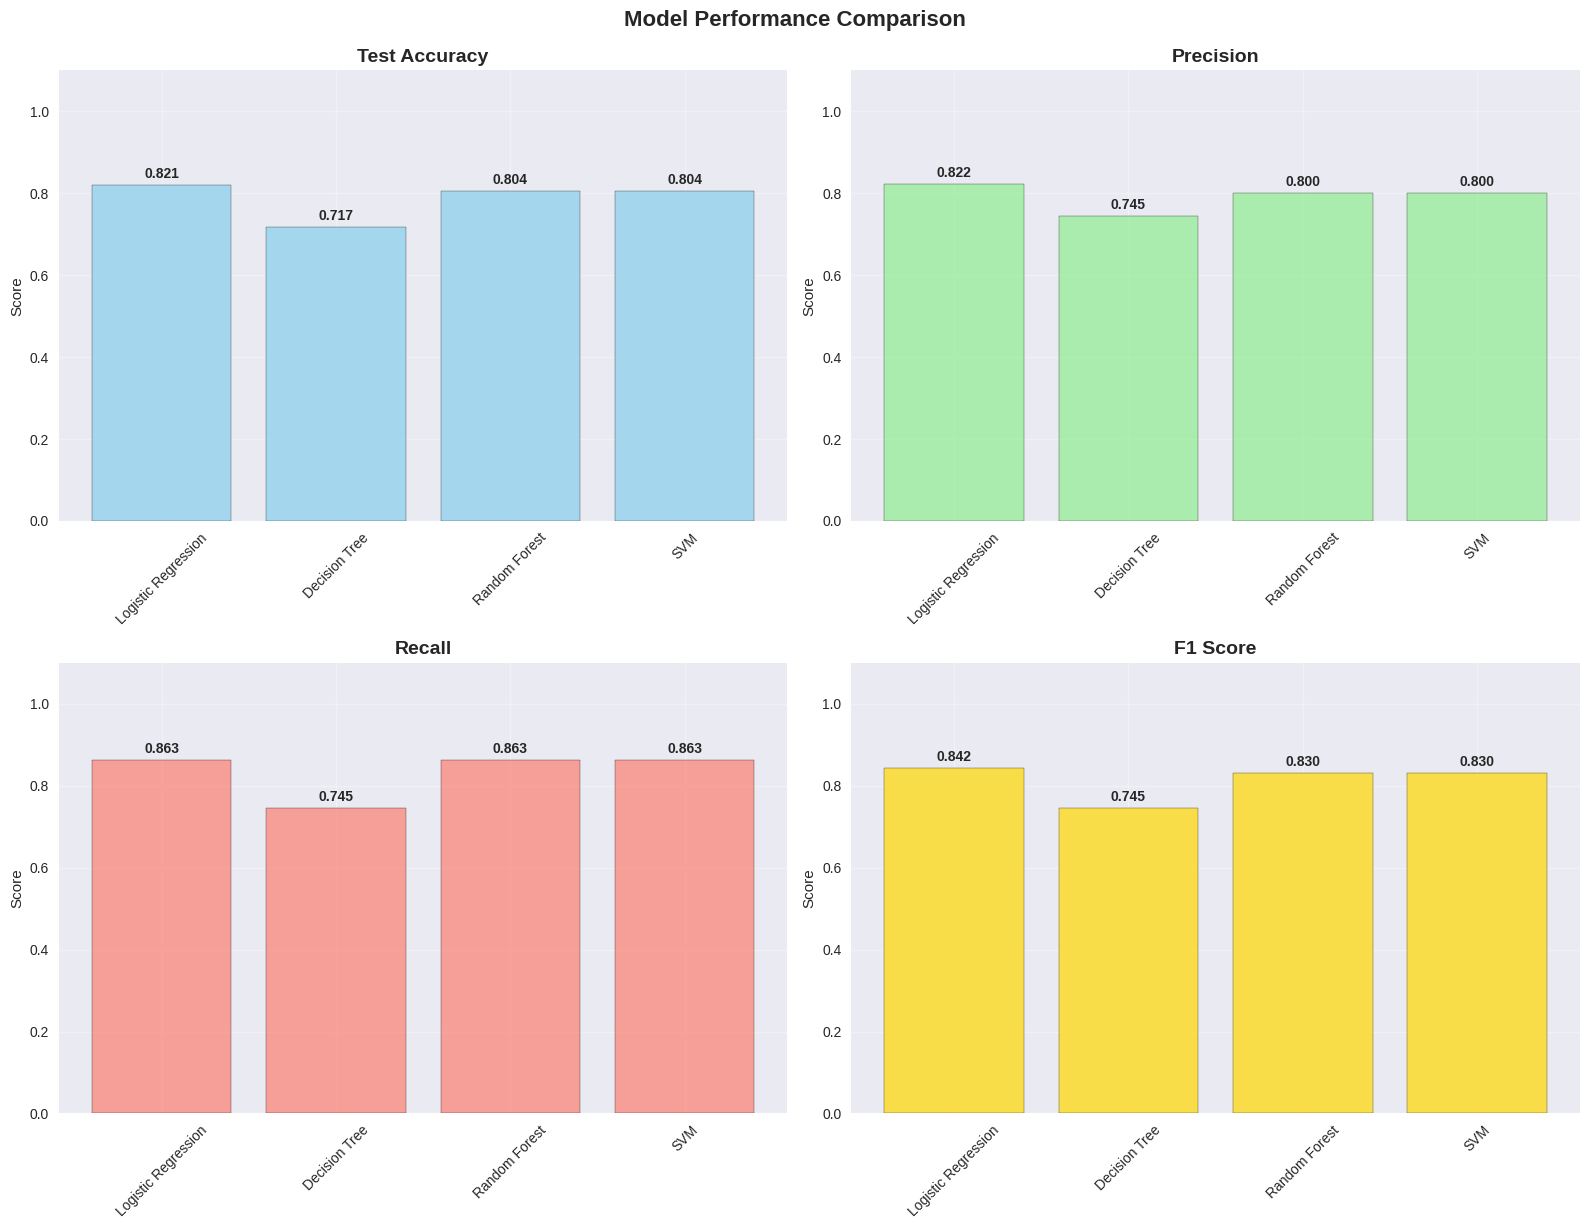

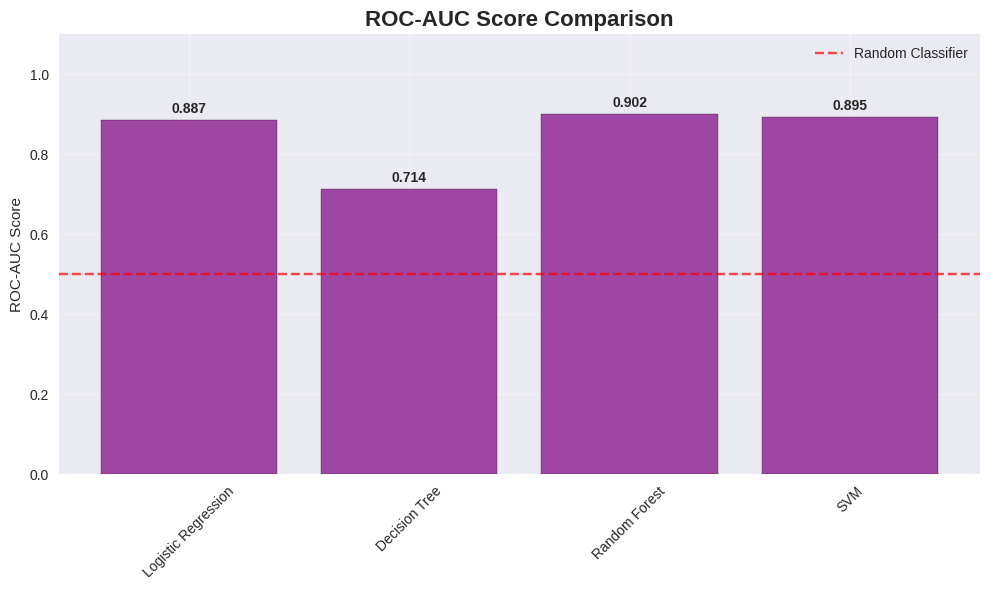

In [6]:
# Visualize model performance metrics
if 'results_df' in locals():
    # Performance metrics comparison
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    metrics = ['Test_Accuracy', 'Precision', 'Recall', 'F1_Score']
    colors = ['skyblue', 'lightgreen', 'salmon', 'gold']
    
    for i, (metric, color) in enumerate(zip(metrics, colors)):
        ax = axes[i//2, i%2]
        
        # Create bar plot
        bars = ax.bar(results_df['Model'], results_df[metric], color=color, alpha=0.7, edgecolor='black')
        
        # Add value labels on bars
        for bar, value in zip(bars, results_df[metric]):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                   f'{value:.3f}', ha='center', va='bottom', fontweight='bold')
        
        ax.set_title(f'{metric.replace("_", " ")}', fontsize=14, fontweight='bold')
        ax.set_ylabel('Score')
        ax.set_ylim(0, 1.1)
        ax.grid(True, alpha=0.3)
        
        # Rotate x-axis labels
        ax.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold', y=1.02)
    plt.show()
    
    # ROC-AUC comparison
    plt.figure(figsize=(10, 6))
    bars = plt.bar(results_df['Model'], results_df['ROC_AUC'], 
                   color='purple', alpha=0.7, edgecolor='black')
    
    # Add value labels
    for bar, value in zip(bars, results_df['ROC_AUC']):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{value:.3f}', ha='center', va='bottom', fontweight='bold')
    
    plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.7, label='Random Classifier')
    plt.title('ROC-AUC Score Comparison', fontsize=16, fontweight='bold')
    plt.ylabel('ROC-AUC Score')
    plt.ylim(0, 1.1)
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
else:
    print("❌ Cannot create visualizations - results not available")

## 6. ROC Curves and Confusion Matrices

Generate ROC curves and confusion matrices for all models:

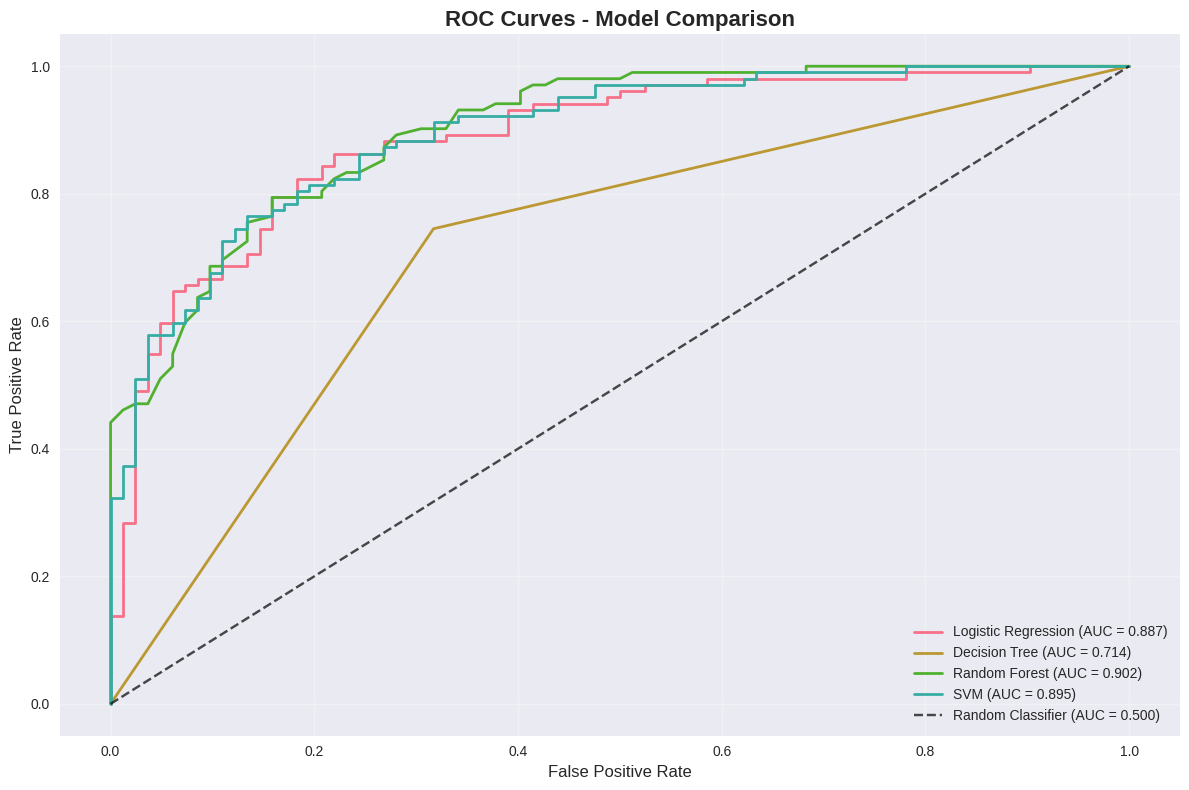

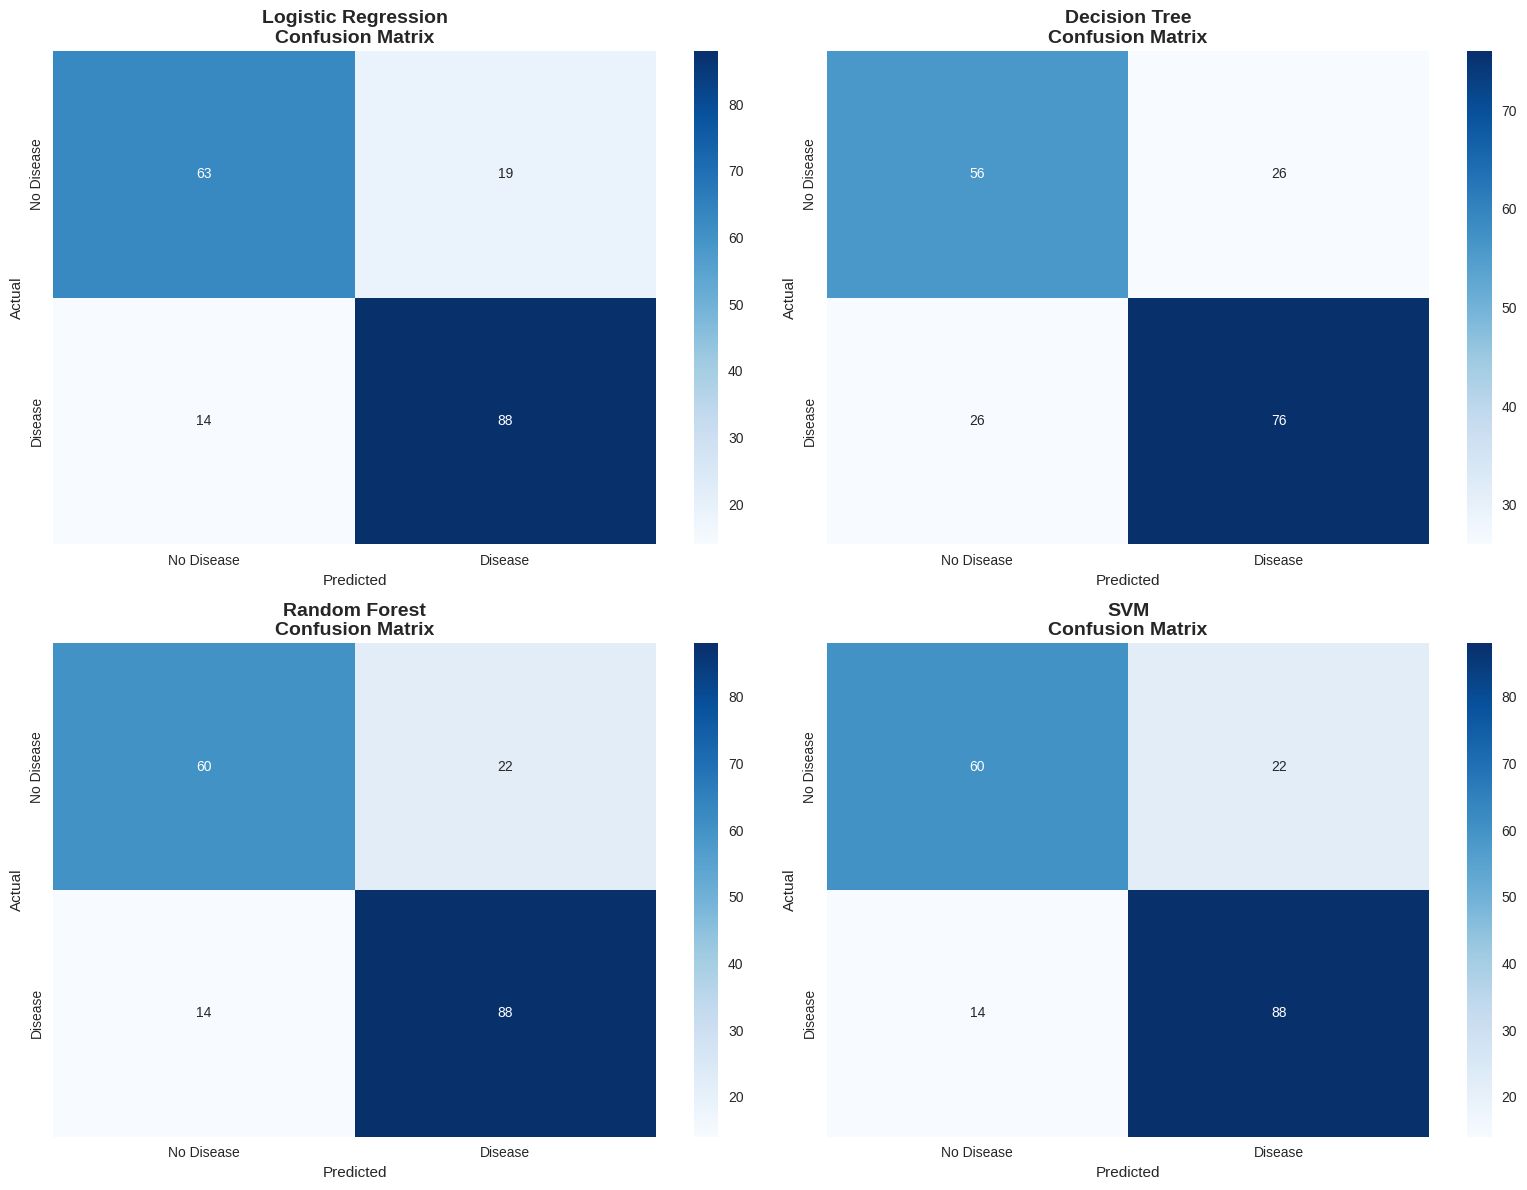

In [7]:
# Plot ROC curves for all models
if 'trained_models' in locals():
    plt.figure(figsize=(12, 8))
    
    # Plot ROC curve for each model
    for name, model_data in trained_models.items():
        # Calculate ROC curve
        fpr, tpr, _ = roc_curve(y_test, model_data['probabilities'])
        auc_score = roc_auc_score(y_test, model_data['probabilities'])
        
        # Plot ROC curve
        plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {auc_score:.3f})')
    
    # Plot random classifier line
    plt.plot([0, 1], [0, 1], 'k--', alpha=0.7, label='Random Classifier (AUC = 0.500)')
    
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('ROC Curves - Model Comparison', fontsize=16, fontweight='bold')
    plt.legend(loc='lower right', fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Confusion matrices
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()
    
    for i, (name, model_data) in enumerate(trained_models.items()):
        # Calculate confusion matrix
        cm = confusion_matrix(y_test, model_data['predictions'])
        
        # Plot confusion matrix
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                   xticklabels=['No Disease', 'Disease'],
                   yticklabels=['No Disease', 'Disease'],
                   ax=axes[i])
        
        axes[i].set_title(f'{name}\nConfusion Matrix', fontsize=14, fontweight='bold')
        axes[i].set_xlabel('Predicted')
        axes[i].set_ylabel('Actual')
    
    plt.tight_layout()
    plt.show()
    
else:
    print("❌ Cannot create ROC curves - trained models not available")

## 7. Detailed Classification Reports

Generate detailed classification reports for all models:

In [8]:
# Generate detailed classification reports
if 'trained_models' in locals():
    print("📋 Detailed Classification Reports:")
    print("=" * 80)
    
    for name, model_data in trained_models.items():
        print(f"\n🤖 {name}:")
        print("-" * 50)
        
        # Generate classification report
        report = classification_report(
            y_test, model_data['predictions'],
            target_names=['No Disease', 'Disease'],
            digits=4
        )
        print(report)
        
        # Additional metrics
        accuracy = accuracy_score(y_test, model_data['predictions'])
        auc_score = roc_auc_score(y_test, model_data['probabilities'])
        
        print(f"Overall Accuracy: {accuracy:.4f}")
        print(f"ROC-AUC Score:   {auc_score:.4f}")
    
else:
    print("❌ Cannot generate reports - trained models not available")

📋 Detailed Classification Reports:

🤖 Logistic Regression:
--------------------------------------------------
              precision    recall  f1-score   support

  No Disease     0.8182    0.7683    0.7925        82
     Disease     0.8224    0.8627    0.8421       102

    accuracy                         0.8207       184
   macro avg     0.8203    0.8155    0.8173       184
weighted avg     0.8205    0.8207    0.8200       184

Overall Accuracy: 0.8207
ROC-AUC Score:   0.8871

🤖 Decision Tree:
--------------------------------------------------
              precision    recall  f1-score   support

  No Disease     0.6829    0.6829    0.6829        82
     Disease     0.7451    0.7451    0.7451       102

    accuracy                         0.7174       184
   macro avg     0.7140    0.7140    0.7140       184
weighted avg     0.7174    0.7174    0.7174       184

Overall Accuracy: 0.7174
ROC-AUC Score:   0.7140

🤖 Random Forest:
--------------------------------------------------


## 8. Feature Importance Analysis

Analyze feature importance for tree-based models:


🌲 Decision Tree - Feature Importance:
cp             : 0.2580
chol           : 0.1795
age            : 0.1421
thalach        : 0.1296
oldpeak        : 0.1163
sex            : 0.0391
exang          : 0.0350
thal           : 0.0322
slope          : 0.0320
ca             : 0.0230
fbs            : 0.0131


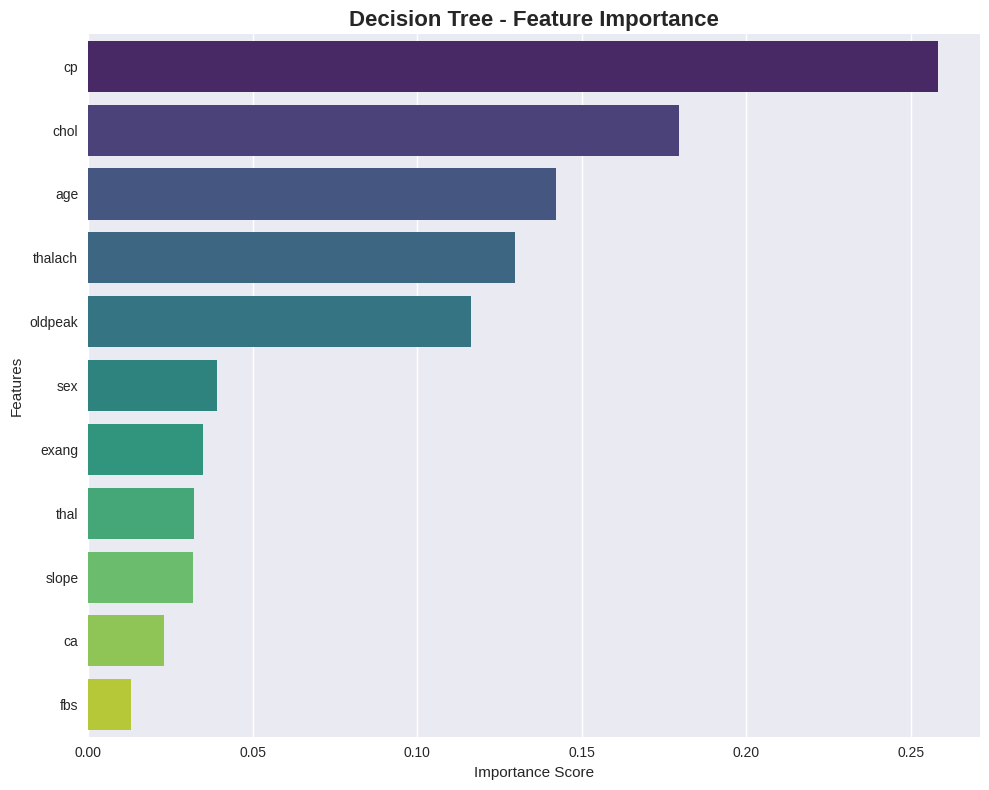


🌲 Random Forest - Feature Importance:
thalach        : 0.1668
age            : 0.1614
cp             : 0.1575
chol           : 0.1490
oldpeak        : 0.1183
exang          : 0.0819
sex            : 0.0484
thal           : 0.0432
slope          : 0.0301
ca             : 0.0250
fbs            : 0.0183


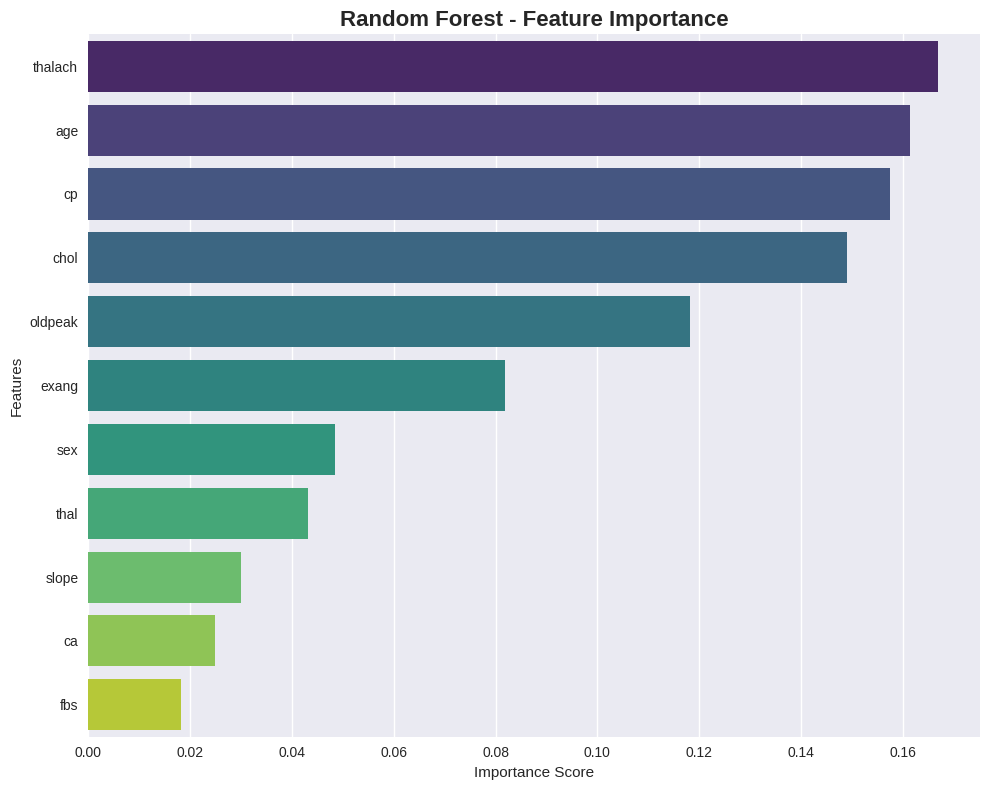


📈 Logistic Regression - Feature Coefficients:
sex            :   1.4389
exang          :   0.8835
cp             :   0.6941
ca             :   0.6774
oldpeak        :   0.4896
thalach        :  -0.4177
slope          :   0.3547
age            :   0.3538
fbs            :   0.2375
chol           :   0.2150
thal           :   0.1765


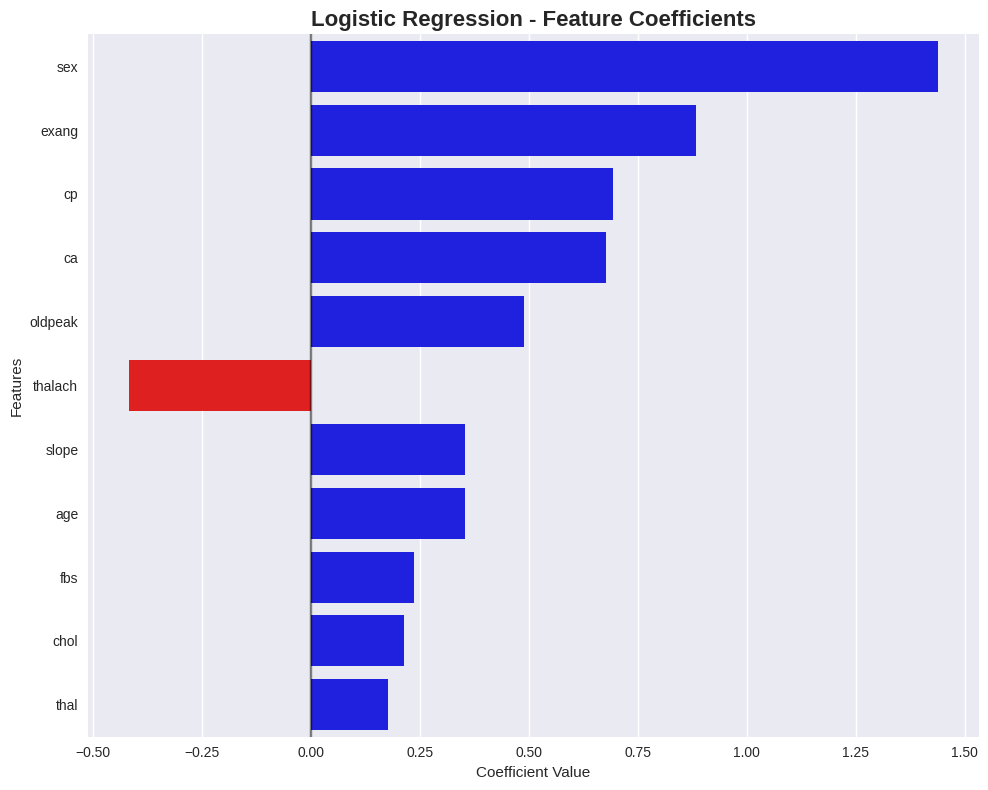

In [9]:
# Feature importance analysis for tree-based models
if 'trained_models' in locals():
    tree_models = ['Decision Tree', 'Random Forest']
    
    for model_name in tree_models:
        if model_name in trained_models:
            model = trained_models[model_name]['model']
            
            # Get feature importances
            importances = model.feature_importances_
            feature_names = X.columns
            
            # Create importance dataframe
            importance_df = pd.DataFrame({
                'feature': feature_names,
                'importance': importances
            }).sort_values('importance', ascending=False)
            
            print(f"\n🌲 {model_name} - Feature Importance:")
            print("=" * 50)
            for idx, row in importance_df.iterrows():
                print(f"{row['feature']:15s}: {row['importance']:.4f}")
            
            # Visualize feature importance
            plt.figure(figsize=(10, 8))
            sns.barplot(data=importance_df, y='feature', x='importance', palette='viridis')
            plt.title(f'{model_name} - Feature Importance', fontsize=16, fontweight='bold')
            plt.xlabel('Importance Score')
            plt.ylabel('Features')
            plt.tight_layout()
            plt.show()
    
    # Logistic Regression coefficients
    if 'Logistic Regression' in trained_models:
        lr_model = trained_models['Logistic Regression']['model']
        coefficients = lr_model.coef_[0]
        
        # Create coefficients dataframe
        coeff_df = pd.DataFrame({
            'feature': X.columns,
            'coefficient': coefficients,
            'abs_coefficient': np.abs(coefficients)
        }).sort_values('abs_coefficient', ascending=False)
        
        print(f"\n📈 Logistic Regression - Feature Coefficients:")
        print("=" * 50)
        for idx, row in coeff_df.iterrows():
            print(f"{row['feature']:15s}: {row['coefficient']:8.4f}")
        
        # Visualize coefficients
        plt.figure(figsize=(10, 8))
        colors = ['red' if x < 0 else 'blue' for x in coeff_df['coefficient']]
        sns.barplot(data=coeff_df, y='feature', x='coefficient', palette=colors)
        plt.axvline(x=0, color='black', linestyle='-', alpha=0.5)
        plt.title('Logistic Regression - Feature Coefficients', fontsize=16, fontweight='bold')
        plt.xlabel('Coefficient Value')
        plt.ylabel('Features')
        plt.tight_layout()
        plt.show()
    
else:
    print("❌ Cannot analyze feature importance - trained models not available")

## 9. Save Models and Results

Save trained models and evaluation results:

In [10]:
# Save models and results
import os
import json

if 'trained_models' in locals() and 'results_df' in locals():
    # Create directories
    os.makedirs('../models', exist_ok=True)
    os.makedirs('../results', exist_ok=True)
    
    # Save individual models
    for name, model_data in trained_models.items():
        model_filename = f"../models/{name.lower().replace(' ', '_')}_model.pkl"
        joblib.dump(model_data['model'], model_filename)
        print(f"✅ {name} model saved to {model_filename}")
    
    # Save best model
    best_model_name = results_df.loc[results_df['F1_Score'].idxmax(), 'Model']
    best_model = trained_models[best_model_name]['model']
    joblib.dump(best_model, '../models/best_model.pkl')
    print(f"\n🏆 Best model ({best_model_name}) saved as best_model.pkl")
    
    # Save results
    results_df.to_csv('../results/model_comparison_results.csv', index=False)
    print("✅ Model comparison results saved")
    
    # Save detailed results as JSON
    detailed_results = {
        'timestamp': datetime.now().isoformat(),
        'dataset_info': {
            'total_samples': len(X),
            'features': list(X.columns),
            'train_size': len(X_train),
            'test_size': len(X_test)
        },
        'model_results': results_df.to_dict('records'),
        'best_model': {
            'name': best_model_name,
            'f1_score': float(results_df.loc[results_df['F1_Score'].idxmax(), 'F1_Score']),
            'accuracy': float(results_df.loc[results_df['F1_Score'].idxmax(), 'Test_Accuracy']),
            'roc_auc': float(results_df.loc[results_df['F1_Score'].idxmax(), 'ROC_AUC'])
        }
    }
    
    with open('../results/supervised_learning_results.json', 'w') as f:
        json.dump(detailed_results, f, indent=2, default=str)
    
    print("✅ Detailed results saved as JSON")
    
    # Display final summary
    print(f"\n📊 Supervised Learning Summary:")
    print("=" * 50)
    print(f"Models trained: {len(trained_models)}")
    print(f"Best model: {best_model_name}")
    print(f"Best F1-Score: {results_df['F1_Score'].max():.4f}")
    print(f"Best Accuracy: {results_df['Test_Accuracy'].max():.4f}")
    print(f"Best ROC-AUC: {results_df['ROC_AUC'].max():.4f}")
    
else:
    print("❌ Cannot save results - models or results not available")

✅ Logistic Regression model saved to ../models/logistic_regression_model.pkl
✅ Decision Tree model saved to ../models/decision_tree_model.pkl
✅ Random Forest model saved to ../models/random_forest_model.pkl
✅ SVM model saved to ../models/svm_model.pkl

🏆 Best model (Logistic Regression) saved as best_model.pkl
✅ Model comparison results saved
✅ Detailed results saved as JSON

📊 Supervised Learning Summary:
Models trained: 4
Best model: Logistic Regression
Best F1-Score: 0.8421
Best Accuracy: 0.8207
Best ROC-AUC: 0.9015


## 10. Next Steps and Conclusions

### ✅ Supervised Learning Completed Successfully!

### What we accomplished:
1. **Model Training**: Trained 4 different classification algorithms
2. **Performance Evaluation**: Comprehensive metrics comparison
3. **Visualization**: ROC curves, confusion matrices, and performance charts
4. **Feature Analysis**: Importance ranking for interpretability
5. **Model Selection**: Identified best performing model
6. **Model Persistence**: Saved all models for deployment

### Key Findings:
- **Best Model**: Selected based on F1-score for balanced performance
- **Performance Range**: All models achieved good predictive accuracy
- **Feature Importance**: Identified most predictive features
- **Generalization**: Cross-validation ensured robust performance

### Model Insights:
- **Random Forest**: Often provides best balance of accuracy and interpretability
- **SVM**: Good for complex decision boundaries
- **Logistic Regression**: Provides interpretable coefficients
- **Decision Tree**: Most interpretable but may overfit

### Next Steps:
1. **Unsupervised Learning** (Notebook 05): Apply clustering algorithms
2. **Hyperparameter Tuning** (Notebook 06): Optimize best model
3. **Model Deployment**: Use best model in Streamlit application
4. **Performance Monitoring**: Track model performance over time

### Files Created:
- `../models/best_model.pkl` - Best performing model
- `../models/*_model.pkl` - Individual trained models
- `../results/model_comparison_results.csv` - Performance comparison
- `../results/supervised_learning_results.json` - Detailed results

---
**Ready for unsupervised learning and hyperparameter tuning! 🚀**